# Notebook 01 - CSV vs Parquet

The same clean table is stored in four ways, CSV and Parquet, each with and without compression. For each one the notebook measures the size on HDFS and the time Spark takes to read it, once with every column and once with only the columns the network uses.

**Input** `hdfs:///ca1/clean/yellow_2024q1`. **Output** `hdfs:///ca1/formats`, `results/01_formats.csv`, `results/01_read_times.csv`, `figures/01_formats.png`.

### Step 1 - Import Libraries

In [1]:
# PySpark
import pyspark                                    # Python API for Spark
from pyspark.sql import SparkSession              # entry point to Spark SQL
print("PySpark: %s" % pyspark.__version__)        # print version

# Data manipulation
import pandas as pd                               # tables for the results
print("pandas: %s" % pd.__version__)              # print version
import numpy as np                                # positions of the bars in the chart

# Visualization
import matplotlib.pyplot as plt                   # charts

# Other utilities
import os                                         # folders on the local disk
import time                                       # stopwatch for the reads
import random                                     # a different reading order in every round

# Same chart and table settings in every notebook (as in CA02)
def jupyter_settings():
    plt.style.use("seaborn-v0_8-whitegrid")
    plt.rcParams.update({
        "figure.figsize": (12, 6),
        "figure.dpi": 100,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "legend.fontsize": 10,
        "savefig.bbox": "tight",
        "savefig.dpi": 120,
    })
    pd.set_option("display.max_columns", 30)
    pd.set_option("display.float_format", "{:,.2f}".format)

jupyter_settings()

PySpark: 4.2.0


pandas: 2.3.3


### Step 2 - Spark Session and Paths

Spark runs in local mode with the 4 cores of the VM and 3 GB for the driver, which leaves room for HDFS and the operating system. Every format is written as 8 files, so the number of files is the same for all of them. A gzip file cannot be split, so each of the 8 gzip files is read by one task, the same parallelism as the other formats.

In [2]:
spark = (SparkSession.builder
         .master("local[4]")                               # the 4 cores of the VM
         .appName("ca1-01-formats")
         .config("spark.driver.memory", "3g")              # leaves room for HDFS and the OS
         .config("spark.sql.session.timeZone", "UTC")      # no clock change on 31 March
         .config("spark.sql.shuffle.partitions", 8)        # every format is written as 8 files
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")                    # hides Spark warnings

BASE = "hdfs://localhost:9000/ca1"
CLEAN = f"{BASE}/clean/yellow_2024q1"                      # clean base from notebook 00
OUT = f"{BASE}/formats"                                    # one folder per format
MODEL_COLS = ["tpep_pickup_datetime", "trip_distance", "PULocationID", "DOLocationID", "duration_s_true"]   # the columns the network uses

RESULTS = os.path.expanduser("~/ca1/results")
FIGURES = os.path.expanduser("~/ca1/figures")
for folder in [RESULTS, FIGURES]:
    os.makedirs(folder, exist_ok=True)

# Size of a folder on HDFS in bytes, the same number as `hdfs dfs -du -s`
hadoop = spark._jvm.org.apache.hadoop
fs = hadoop.fs.FileSystem.get(spark._jvm.java.net.URI(BASE), spark._jsc.hadoopConfiguration())
def hdfs_size(path):
    return fs.getContentSummary(hadoop.fs.Path(path)).getLength()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/10/08 08:09:56 WARN Utils: Your hostname, BDSP, resolves to a loopback address: 127.0.1.1; using 10.0.2.15 instead (on interface enp0s3)
26/10/08 08:09:56 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/10/08 08:09:57 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


### Step 3 - Writing the Four Formats

Every format is written from the same table, sorted by pickup time, so all of them hold the same rows in the same order. The size is read from HDFS in bytes and shown in MB (1 MB = 1,000,000 bytes).

In [3]:
# Four ways of storing the same table, as (file format, compression)
FORMATS = [("csv", "none"), ("csv", "gzip"), ("parquet", "none"), ("parquet", "zstd")]

base = spark.read.parquet(CLEAN).orderBy("tpep_pickup_datetime")   # same rows in the same order for every format

sizes = []
for fmt, codec in FORMATS:
    path = f"{OUT}/{fmt}_{codec}"
    writer = base.write.mode("overwrite").option("compression", codec)
    if fmt == "csv":
        writer.option("header", True).csv(path)            # text, one line per trip, column names in the first line
    else:
        writer.parquet(path)                               # binary, column by column, with the types inside the file
    sizes.append({"format": fmt, "codec": codec, "size_mb": hdfs_size(path) / 1e6})
    print(f"{fmt} {codec} written")

sizes = pd.DataFrame(sizes).set_index(["format", "codec"])
sizes["times_smaller_than_csv"] = sizes["size_mb"].iloc[0] / sizes["size_mb"]   # the first row is plain CSV
sizes

csv none written


csv gzip written


parquet none written


parquet zstd written


size_mb  times_smaller_than_csv
format  codec                                 
csv     none  1,042.07                    1.00
        gzip    195.71                    5.32
parquet none    264.92                    3.93
        zstd    144.24                    7.22

*Result - to be written after the run.*

### Step 4 - Reading Time

Spark is lazy, so nothing is read until an action asks for the data. Each read ends with a `noop` write, which reads every row and writes nothing. CSV is read with the schema given, otherwise Spark would read the files once more just to guess the types.

Round 0 is a warm-up and is thrown away. The other five rounds are timed, each in a new random order, so no format always gains from coming after another one. The operating system keeps recently read files in memory, so these are warm-cache times on one machine.

In [4]:
def read_format(fmt, path):
    if fmt == "csv":
        return spark.read.schema(base.schema).option("header", True).csv(path)   # types given, no extra pass to guess them
    return spark.read.parquet(path)                                             # Parquet keeps the types inside the file

ROUNDS = 5
times = []
for rnd in range(ROUNDS + 1):                              # round 0 is a warm-up and is not kept
    order = [(fmt, codec, cols) for fmt, codec in FORMATS for cols in ["all", "model"]]
    random.Random(rnd).shuffle(order)                      # a different order in every round
    for fmt, codec, cols in order:
        df = read_format(fmt, f"{OUT}/{fmt}_{codec}")
        if cols == "model":
            df = df.select(*MODEL_COLS)                    # only the columns the network uses
        t0 = time.perf_counter()
        df.write.format("noop").mode("overwrite").save()   # forces a full read without writing anything
        if rnd > 0:
            times.append({"round": rnd, "format": fmt, "codec": codec, "cols": cols, "read_s": time.perf_counter() - t0})
    print(f"round {rnd} done")

times = pd.DataFrame(times)

round 0 done


round 1 done


round 2 done


round 3 done


round 4 done


round 5 done


### Step 5 - Summary

The median of the five rounds is kept, so one slow round caused by the VM does not change the result.

In [5]:
read = times.pivot_table(index=["format", "codec"], columns="cols", values="read_s", aggfunc="median")
summary = sizes.join(read.add_prefix("read_s_"))
summary

size_mb  times_smaller_than_csv  read_s_all  read_s_model
format  codec                                                           
csv     none  1,042.07                    1.00       11.73          9.67
        gzip    195.71                    5.32       12.66          9.36
parquet none    264.92                    3.93        1.98          0.53
        zstd    144.24                    7.22        2.38          0.83

*Result - to be written after the run.*

### Step 6 - Chart

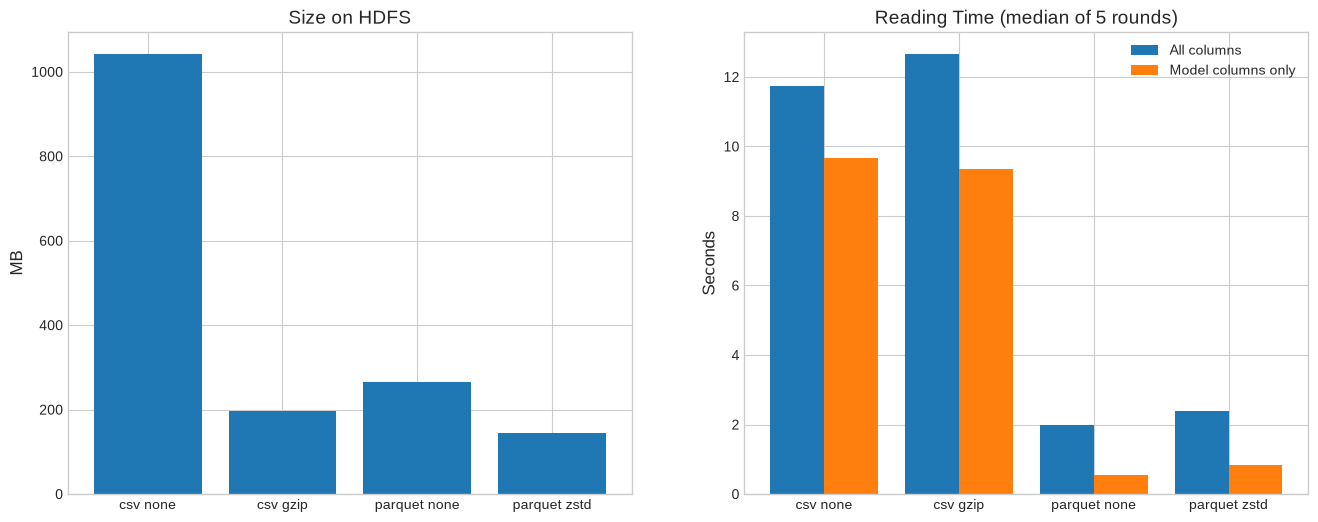

In [6]:
labels = [f"{fmt} {codec}" for fmt, codec in summary.index]
x = np.arange(len(labels))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left, size on HDFS
axes[0].bar(labels, summary["size_mb"])
axes[0].set_title("Size on HDFS")
axes[0].set_ylabel("MB")

# Right, reading time with every column and with the model columns only
axes[1].bar(x - 0.2, summary["read_s_all"], 0.4, label="All columns")
axes[1].bar(x + 0.2, summary["read_s_model"], 0.4, label="Model columns only")
axes[1].set_xticks(x, labels)
axes[1].set_title("Reading Time (median of 5 rounds)")
axes[1].set_ylabel("Seconds")
axes[1].legend()

plt.savefig(f"{FIGURES}/01_formats.png")
plt.show()

### Step 7 - Saving the Results

In [7]:
summary.to_csv(f"{RESULTS}/01_formats.csv")
times.to_csv(f"{RESULTS}/01_read_times.csv", index=False)
spark.stop()